In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

PyTorch: 2.9.1+cu128
CUDA available: True
GPU name: Quadro RTX 5000


In [ ]:
from ultralytics import YOLO

# chọn model nhẹ để test trước
model = YOLO("yolov8n.pt")   # hoặc yolov8s.pt nếu GPU khỏe

results = model.train(
    data="vnfoods_det.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,       # early stopping
    project="runs_yolo",
    name="vnfoods_det",
    exist_ok=True
)


Ultralytics 8.3.228 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 5000, 15925MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vnfoods_det.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=vnfoods_det, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=1

Corrupt JPEG data: 229 extraneous bytes before marker 0xd9


      1/100      2.08G          0      36.05          0          0        640: 60% ━━━━━━━───── 847/1407 7.2it/s 3:01<1:17

Corrupt JPEG data: 9 extraneous bytes before marker 0xe2


      1/100      2.09G          0      21.73          0          0        640: 100% ━━━━━━━━━━━━ 1407/1407 4.4it/s 5:22<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 3.3it/s 32.9s0.1ss


/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/.venv/lib/python3.10/site-packages/ultralytics/utils/metrics.py:829: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


                   all       3519          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.22G          0          0          0          0        640: 7% ╸─────────── 104/1407 7.7it/s 15.4s<2:49

Corrupt JPEG data: 9 extraneous bytes before marker 0xe2


      2/100      3.22G          0          0          0          0        640: 16% ━╸────────── 230/1407 8.3it/s 41.1s<2:21


image 1/1 /home/mtl/Downloads/hhh.jpg: 480x640 (no detections), 108.7ms
Speed: 22.8ms preprocess, 108.7ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


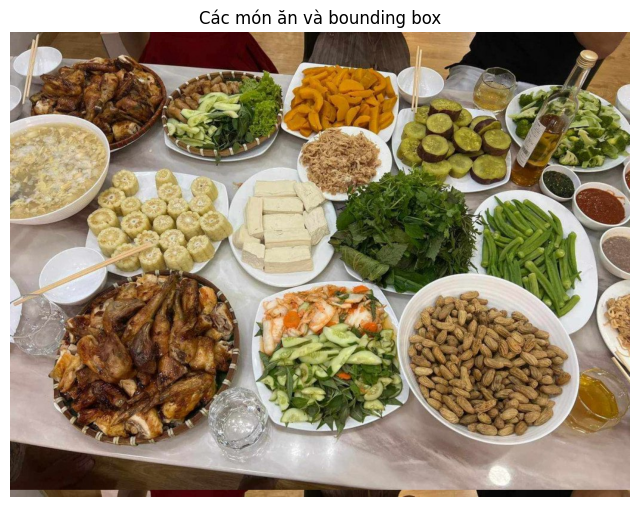

In [ ]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

best_ckpt = Path("runs_yolo/vnfoods_det/weights/best.pt")
det_model = YOLO(best_ckpt)

#IMG_PATH = Path("/media/mtl/Downloads/ban-an-example.jpg")  # ảnh bàn ăn nhiều món
IMG_PATH = Path("/home/mtl/Downloads/hhh.jpg")   


results = det_model(
    source=str(IMG_PATH),
    conf=0.25,        # ngưỡng tin cậy, có thể tăng lên 0.4 để bớt rác
    iou=0.45,
    save=False
)

r = results[0]

# vẽ bằng .plot()
det_img = r.plot()  # numpy array BGR
det_img = det_img[..., ::-1]  # đổi sang RGB

plt.figure(figsize=(8,8))
plt.imshow(det_img)
plt.axis("off")
plt.title("Các món ăn và bounding box")
plt.show()

# In ra danh sách món phát hiện
for box in r.boxes:
    cls_id = int(box.cls[0])
    conf   = float(box.conf[0])
    label  = det_model.names[cls_id]
    print(f"{label:20s} - conf={conf:.2f}")



from ultralytics import YOLO
seg = YOLO("yolov8s-seg.pt")
results = seg(img)



In [3]:
# Cell 1: Import & cấu hình đường dẫn

import os
from pathlib import Path
import sys
import shutil
from collections import defaultdict

import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ultralytics import YOLO  # pip install ultralytics

# ==== CẤU HÌNH PROJECT ROOT (sửa lại nếu khác) ====
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("ROOT =", ROOT)

# ==== ĐƯỜNG DẪN DATASET GỐC (Classification) ====
# Thư mục ảnh hiện tại của bạn:
# /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Train/...
DATASET_IMG_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images")

# Train/Val gốc để auto-label
SRC_TRAIN_DIR = DATASET_IMG_ROOT / "Train"
SRC_VAL_DIR   = DATASET_IMG_ROOT / "Validate"

print("SRC_TRAIN_DIR =", SRC_TRAIN_DIR)
print("SRC_VAL_DIR   =", SRC_VAL_DIR)

# ==== THƯ MỤC YOLO DATASET MỚI ====
YOLO_DATASET_ROOT = ROOT / "yolo_dataset"
YOLO_IMG_TRAIN = YOLO_DATASET_ROOT / "images" / "train"
YOLO_IMG_VAL   = YOLO_DATASET_ROOT / "images" / "val"
YOLO_LBL_TRAIN = YOLO_DATASET_ROOT / "labels" / "train"
YOLO_LBL_VAL   = YOLO_DATASET_ROOT / "labels" / "val"

for d in [YOLO_IMG_TRAIN, YOLO_IMG_VAL, YOLO_LBL_TRAIN, YOLO_LBL_VAL]:
    d.mkdir(parents=True, exist_ok=True)
    print("Created:", d)


ROOT = /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
SRC_TRAIN_DIR = /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Train
SRC_VAL_DIR   = /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Validate
Created: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/yolo_dataset/images/train
Created: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/yolo_dataset/images/val
Created: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/yolo_dataset/labels/train
Created: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/yolo_dataset/labels/val


In [8]:
# Cell 3: Load model EfficientNet + checkpoint mới nhất

import sys
from pathlib import Path
import torch

# 1) Lấy project root
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✅ Added to sys.path:", ROOT)

# 2) Import model từ folder /model
from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# 3) Khởi tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 33
model = MTLEfficientNetB0(num_classes=num_classes)
model.to(device)

print("Thiết bị:", device)

# 4) Tìm checkpoint mtl_efficientnet_b0_best.pt trong các folder con của /Jupyter/runs
runs_dir = ROOT / "Jupyter" / "runs"
print("📁 runs_dir:", runs_dir)

# lấy tất cả file *best.pt
ckpt_list = sorted(runs_dir.rglob("*best.pt"))
print("\n🔍 Found checkpoints:")
for p in ckpt_list:
    print("  -", p)

if not ckpt_list:
    raise FileNotFoundError("❌ Không tìm thấy bất kỳ file '*best.pt' nào trong thư mục 'runs/'")

# => Lấy file checkpoint mới nhất
CKPT_PATH = ckpt_list[-1]
print("\n✅ Using checkpoint:", CKPT_PATH)

# 5) Load weight
ckpt = torch.load(CKPT_PATH, map_location=device)

# ---- CHỖ QUAN TRỌNG: bóc đúng state_dict của model ----
if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    # Trường hợp bạn save thẳng model.state_dict(...)
    state_dict = ckpt

# Nếu trong state_dict có prefix kiểu "model." thì bỏ đi
from collections import OrderedDict
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_k = k
    if new_k.startswith("model."):
        new_k = new_k[len("model."):]
    clean_state_dict[new_k] = v

# Load vào model (strict=False để bỏ qua key thừa/thiếu nhẹ)
missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

print("\n🔁 load_state_dict done.")
print("   Missing keys:", missing)
print("   Unexpected keys:", unexpected)

model.eval()
print("\n✅ Model loaded & set to eval().")


✅ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
Thiết bị: cuda
📁 runs_dir: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs

🔍 Found checkpoints:
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-101729/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

✅ Using checkpoint: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

🔁 load_state_dict done.
   Missing keys: ['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'ba

In [9]:
# Cell 3: Transform & helper classify_patch

# Giả định input model là 224x224, chuẩn hóa ImageNet
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_cls = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

@torch.no_grad()
def classify_patch(pil_patch, topk=1):
    """Nhận 1 PIL Image patch, trả về (class_id, class_name, prob)"""
    x = transform_cls(pil_patch).unsqueeze(0).to(device)
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    prob, cls_idx = probs.max(dim=1)
    cls_idx = cls_idx.item()
    prob = prob.item()
    cls_name = CLASS_NAMES[cls_idx]
    return cls_idx, cls_name, prob


In [10]:
# Cell 4: Load YOLOv8-seg pretrained & helper detect

# Model seg dùng để tìm vùng vật thể (tô, chén, đồ ăn,...)
# Có thể dùng 'yolov8s-seg.pt' hoặc 'yolov8n-seg.pt'
yolo_seg = YOLO("yolov8s-seg.pt")  # sẽ tự tải về lần đầu
yolo_seg.to(device)
print("✅ YOLOv8-seg loaded.")

def run_yolo_segment(pil_img, conf_thres=0.3):
    """
    Chạy YOLOv8-seg trên 1 PIL image.
    Trả về list bbox: (x1, y1, x2, y2).
    Có thể filter theo class name nếu muốn (vd: bowl, cup, plate,...)
    """
    results = yolo_seg.predict(pil_img, conf=conf_thres, verbose=False)
    boxes = []
    if not results:
        return boxes

    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return boxes

    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        boxes.append((x1, y1, x2, y2))
    return boxes


✅ YOLOv8-seg loaded.


In [11]:
# Cell 5: Helper crop patch, convert bbox → YOLO format

def crop_patch(pil_img, bbox, pad_ratio=0.05):
    """Crop patch từ bbox (x1,y1,x2,y2), có padding chút cho đẹp."""
    w, h = pil_img.size
    x1, y1, x2, y2 = bbox
    pad_x = (x2 - x1) * pad_ratio
    pad_y = (y2 - y1) * pad_ratio
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)
    return pil_img.crop((x1, y1, x2, y2))

def bbox_xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    """Convert bbox góc (x1,y1,x2,y2) sang YOLO format."""
    bw = x2 - x1
    bh = y2 - y1
    cx = x1 + bw / 2
    cy = y1 + bh / 2
    return cx / img_w, cy / img_h, bw / img_w, bh / img_h


In [12]:
# Cell 5: Helper crop patch, convert bbox → YOLO format

def crop_patch(pil_img, bbox, pad_ratio=0.05):
    """Crop patch từ bbox (x1,y1,x2,y2), có padding chút cho đẹp."""
    w, h = pil_img.size
    x1, y1, x2, y2 = bbox
    pad_x = (x2 - x1) * pad_ratio
    pad_y = (y2 - y1) * pad_ratio
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)
    return pil_img.crop((x1, y1, x2, y2))

def bbox_xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    """Convert bbox góc (x1,y1,x2,y2) sang YOLO format."""
    bw = x2 - x1
    bh = y2 - y1
    cx = x1 + bw / 2
    cy = y1 + bh / 2
    return cx / img_w, cy / img_h, bw / img_w, bh / img_h


Kích thước ảnh: 800 x 500
Số region phát hiện: 3
Số vùng được chấp nhận: 0


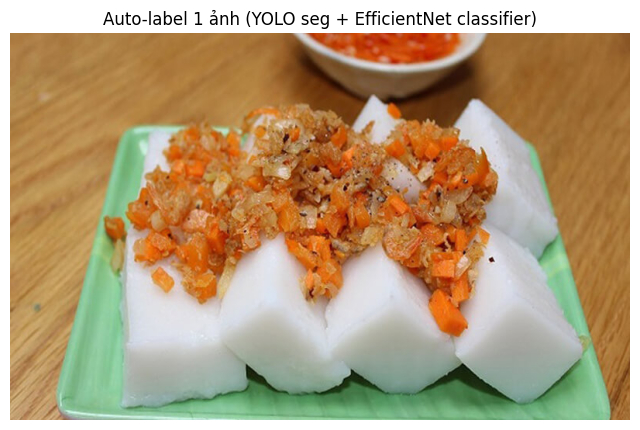

In [15]:
# Cell 6: Test auto-label trên 1 ảnh bất kỳ
TEST_IMG_PATH = Path("/home/mtl/Downloads/f.jpg")   

pil_img = Image.open(TEST_IMG_PATH).convert("RGB")
img_w, img_h = pil_img.size
print("Kích thước ảnh:", img_w, "x", img_h)

# 1) YOLO-seg tìm vùng
boxes = run_yolo_segment(pil_img, conf_thres=0.4)
print("Số region phát hiện:", len(boxes))

# 2) Phân loại từng patch
THRESH_CLASS = 0.6  # ngưỡng chấp nhận món ăn
det_results = []    # list (cls_id, cls_name, prob, bbox)

for bbox in boxes:
    patch = crop_patch(pil_img, bbox, pad_ratio=0.05)
    cls_id, cls_name, prob = classify_patch(patch)
    if prob < THRESH_CLASS:
        continue
    det_results.append((cls_id, cls_name, prob, bbox))

print("Số vùng được chấp nhận:", len(det_results))

# 3) Vẽ kết quả
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(pil_img)
ax.axis("off")

for cls_id, cls_name, prob, (x1, y1, x2, y2) in det_results:
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        x1,
        y1 - 5,
        f"{cls_name} ({prob:.2f})",
        color="yellow",
        fontsize=10,
        bbox=dict(facecolor="red", alpha=0.5, edgecolor="none"),
    )

plt.title("Auto-label 1 ảnh (YOLO seg + EfficientNet classifier)")
plt.show()
